In [1]:
import pandas as pd
import numpy as np
import tensorflow
import nltk  # Natural language processing package
import bleach  # Remove HTML tags
import re  # For handling regular expression in the text
from tensorflow.keras.models import Sequential #importing the sequential model 
from tensorflow.keras.layers import Embedding, LSTM, Dense # importing the required layers for the LSTM
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.text import Tokenizer # for tokenizing the text 
from tensorflow.keras.preprocessing.sequence import pad_sequences # for correcting the dimentions of the test and training data.
from sklearn.model_selection import train_test_split #Ttrain-test spilt
from sklearn.preprocessing import LabelEncoder #label encoding for sentimental_score column
from sklearn.metrics import accuracy_score,classification_report #for finding the accuracy score and producing the classification report 
from nltk.stem import WordNetLemmatizer  # For lemmatization process
from nltk.tokenize import word_tokenize  #For tokkenising the text
from nltk.sentiment import SentimentIntensityAnalyzer  # For performing sentimental analysis of the tweet
from nltk.stem import PorterStemmer # for performing stemming of the text 
from nltk.corpus import stopwords  # For removing stop words
from emoji import demojize  # Convert emojis to text
from keras.models import Sequential
from keras.layers import Embedding, LSTM, Dense
from sklearn.metrics import roc_auc_score
from keras.callbacks import Callback
from tabulate import tabulate
from keras.models import load_model
import tensorflow as tf
nltk.download('wordnet')
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('vader_lexicon')

[nltk_data] Downloading package wordnet to C:\Users\My
[nltk_data]     PC\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\My
[nltk_data]     PC\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to C:\Users\My
[nltk_data]     PC\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package vader_lexicon to C:\Users\My
[nltk_data]     PC\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

SOCIAL-USERS(ACCOUNT DESCRIPTION-LSTM)

In [2]:
df = pd.read_csv("D:\RPP\SOCIAL USERS-CODE\sample_social_users.csv",low_memory=False)
df.dropna()
df['description'] = df['description'].astype(str)
# Lowercase text
df["description"] = df["description"].str.lower()
print(df.description)
df.columns

0                                                     nan
1       autrice del libro #unavitatuttacurve dal 9 apr...
2                                 [live long and prosper]
3       cuasi odontologa*♥,#bipolar, #sarcastica & som...
4       i shall rise from my own death, to avenge hers...
                              ...                        
2494                                                  nan
2495                                                  nan
2496                                                  nan
2497                                                  nan
2498                                                  nan
Name: description, Length: 2499, dtype: object


Index(['id', 'name', 'screen_name', 'statuses_count', 'followers_count',
       'friends_count', 'favourites_count', 'listed_count', 'url', 'lang',
       'time_zone', 'location', 'default_profile', 'default_profile_image',
       'geo_enabled', 'profile_image_url', 'profile_banner_url',
       'profile_use_background_image', 'profile_background_image_url_https',
       'profile_text_color', 'profile_image_url_https',
       'profile_sidebar_border_color', 'profile_background_tile',
       'profile_sidebar_fill_color', 'profile_background_image_url',
       'profile_background_color', 'profile_link_color', 'utc_offset',
       'is_translator', 'follow_request_sent', 'protected', 'verified',
       'notifications', 'description', 'contributors_enabled', 'following',
       'created_at', 'timestamp', 'crawled_at', 'updated', 'test_set_1'],
      dtype='object')

In [3]:
df['description'].fillna('.', inplace=True)
df.description

0                                                     nan
1       autrice del libro #unavitatuttacurve dal 9 apr...
2                                 [live long and prosper]
3       cuasi odontologa*♥,#bipolar, #sarcastica & som...
4       i shall rise from my own death, to avenge hers...
                              ...                        
2494                                                  nan
2495                                                  nan
2496                                                  nan
2497                                                  nan
2498                                                  nan
Name: description, Length: 2499, dtype: object

In [4]:
# Remove punctuation and special characters
def clean_text(text):
    text = re.sub(r"[^a-zA-Z0-9\s]", "", text)
    return text
df["description"] = df["description"].apply(clean_text)

In [5]:
#Removal of stop words
stop_words = stopwords.words("english")
def remove_stop_words(text):
    words = [word for word in text.split() if word not in stop_words]
    return " ".join(words)
df["description"] = df["description"].apply(remove_stop_words)

In [6]:
#Removal of htmltags from the text
def remove_html_tags(text):
    return bleach.clean(text, tags=[], strip=True)
df["description"] = df["description"].apply(remove_html_tags)

In [7]:
# Handle negations
def handle_negations(text):
    negations = {"no", "not", "never", "none", "can't", "couldn't", "didn't", "doesn't", "don't", "isn't", "wasn't", "won't"}
    words = text.split()
    negated_words = [word for word in words if word in negations]
    for word in negated_words:
        index = words.index(word)
        if index < len(words) - 1:
            words[index + 1] = f"NOT_{words[index + 1]}"
    return " ".join(words)
df["description"] = df["description"].apply(handle_negations)

In [8]:
# demojizing  the  text
def convert_emojis(text):
    return demojize(text)
df["description"] = df["description"].apply(convert_emojis)

In [9]:
#Segmentation
def perform_word_segmentation(text):
    tokens = nltk.word_tokenize(text)
    segmented_words = ' '.join(tokens)  # Join the words back into a string
    return segmented_words
# Applying the word segmentation function to the selected column
df['segmented_words'] = df["description"].apply(perform_word_segmentation)
# Display the original and segmented text
print("Original description:")
print(df["description"].head())
print("\nSegmented Words:")
print(df['segmented_words'].head())

Original description:
0                                                  nan
1    autrice del libro unavitatuttacurve dal 9 apri...
2                                    live long prosper
3    cuasi odontologabipolar sarcastica might say i...
4              shall rise death avenge powers darkness
Name: description, dtype: object

Segmented Words:
0                                                  nan
1    autrice del libro unavitatuttacurve dal 9 apri...
2                                    live long prosper
3    cuasi odontologabipolar sarcastica might say i...
4              shall rise death avenge powers darkness
Name: segmented_words, dtype: object


In [10]:
# lemmatization
ps = PorterStemmer()
lemmatizer = WordNetLemmatizer()
def lemmatize_text(segmented_words):
    if pd.notna(segmented_words):
        words = segmented_words.split()
        lemmatized_words = [lemmatizer.lemmatize(word) for word in words]
        return " ".join(lemmatized_words)
    else:
        return ""
# Apply the lemmatization function to the "segmented_words" column
df["segmented_words"] = df["segmented_words"].apply(lemmatize_text)
# Display the lemmatized words
print(df["segmented_words"])
# Save the cleaned data
df.to_csv("D:\RPP\SOCIAL USERS-CODE\presocial_users.csv", index=False)

0                                                     nan
1       autrice del libro unavitatuttacurve dal 9 apri...
2                                       live long prosper
3       cuasi odontologabipolar sarcastica might say i...
4                  shall rise death avenge power darkness
                              ...                        
2494                                                  nan
2495                                                  nan
2496                                                  nan
2497                                                  nan
2498                                                  nan
Name: segmented_words, Length: 2499, dtype: object


In [11]:
print(type(df['segmented_words']))

<class 'pandas.core.series.Series'>


In [12]:
df=pd.read_csv("D:\RPP\SOCIAL USERS-CODE\presocial_users.csv",low_memory=False)
df.segmented_words

0                                                     NaN
1       autrice del libro unavitatuttacurve dal 9 apri...
2                                       live long prosper
3       cuasi odontologabipolar sarcastica might say i...
4                  shall rise death avenge power darkness
                              ...                        
2494                                                  NaN
2495                                                  NaN
2496                                                  NaN
2497                                                  NaN
2498                                                  NaN
Name: segmented_words, Length: 2499, dtype: object

In [13]:
#Function for calculating the sentimental_score of the description
def calculate_sentiment_score(text):
    if pd.isnull(text):
        return np.nan
    analyzer = SentimentIntensityAnalyzer()
    sentiment_scores = analyzer.polarity_scores(str(text))
    return sentiment_scores['compound']

In [14]:
text_column = 'segmented_words'
# Create a SentimentIntensityAnalyzer instance
analyzer = SentimentIntensityAnalyzer()
# Use vectorized operations to calculate sentiment scores
df['sentiment_score'] = df[text_column].apply(lambda x: analyzer.polarity_scores(str(x))['compound'])

In [15]:
print(df.sentiment_score)

0       0.0000
1       0.0000
2       0.0000
3      -0.1280
4      -0.7096
         ...  
2494    0.0000
2495    0.0000
2496    0.0000
2497    0.0000
2498    0.0000
Name: sentiment_score, Length: 2499, dtype: float64


In [16]:
# Creating a new column named label based on the sentiment_score value.
df['label'] = (df['sentiment_score'] > 0).astype(float) * 1 + (df['sentiment_score'] < 0).astype(float) * -1 

In [17]:
df['segmented_words'].fillna('.', inplace=True)

In [18]:
file_path = "D:\RPP\SOCIAL USERS-CODE\pre_social_label.csv"

# Save the DataFrame to CSV
df.to_csv(file_path, index=False)

In [19]:
print(df[['segmented_words','sentiment_score','label']])

                                        segmented_words  sentiment_score  \
0                                                     .           0.0000   
1     autrice del libro unavitatuttacurve dal 9 apri...           0.0000   
2                                     live long prosper           0.0000   
3     cuasi odontologabipolar sarcastica might say i...          -0.1280   
4                shall rise death avenge power darkness          -0.7096   
...                                                 ...              ...   
2494                                                  .           0.0000   
2495                                                  .           0.0000   
2496                                                  .           0.0000   
2497                                                  .           0.0000   
2498                                                  .           0.0000   

      label  
0       0.0  
1       0.0  
2       0.0  
3      -1.0  
4      -1.0  
...

In [20]:
# Function for loading the glove_embedding model.
def load_glove_model(glove_file):
    glove_model = {}
    with open(glove_file, 'r', encoding='utf-8') as file:
        for line in file:
            elements = line.split()
            word = elements[0]
            coefs = np.array(elements[1:], dtype='object')
            glove_model[word] = coefs
    print(f"{len(glove_model)} words loaded!")
    return glove_model

In [21]:
# Function for converting the text in glove_embedded vectors.
def text_to_embeddings(segmented_words, glove_model):
    words = segmented_words.split()
    embeddings = []
    for word in words:
        if word in glove_model:
            embeddings.append(glove_model[word])
        else:
            embeddings.append(np.zeros(50))  # Handle unknown words
    return np.array(embeddings,dtype='object')

In [22]:
# Function for applying the glove_model.
def apply_glove_embeddings(df, text_columns, glove_model):
    new_df = pd.DataFrame()
    for column in text_columns:
        new_column_name = f'{column}_glove_embeddings'
        new_df[new_column_name] = df[column].apply(lambda x: text_to_embeddings(str(x), glove_model))
    return new_df

In [23]:
if __name__ == "__main__":
    # Load the GloVe  model.
    glove_model = load_glove_model("D:\RPP\WORD EMBEDING\glove.twitter.27B.50d.txt") 
    text_columns_to_embed = ['segmented_words']
    new_df_with_embeddings = apply_glove_embeddings(df, text_columns_to_embed, glove_model)
    df = pd.concat([df, new_df_with_embeddings], axis=1)

1193515 words loaded!


In [24]:
print(df['label'].dtype)

float64


In [25]:
s = 0.0

# Iterate over the 'description' column instead of 'segmented_words'
for description in df['segmented_words']:
    if not pd.isna(description):
        word_list = description.split()
        s += len(word_list)

# Calculate the average length
average_length = s / len(df['description'].dropna())
print("Average length of each description: ", average_length)

df['label'] = df['label'].astype(str)

# Count positive, negative, and neutral descriptions
positive_count = df[df['label'] == '1.0'].shape[0]
negative_count = df[df['label'] == '-1.0'].shape[0]
neutral_count = df[df['label'] == '0.0'].shape[0]
total_descriptions = df.shape[0]

# Calculate percentages
percentage_positive = (positive_count / total_descriptions) * 100
percentage_negative = (negative_count / total_descriptions) * 100
percentage_neutral = (neutral_count / total_descriptions) * 100

# Print results
print("Percentage of descriptions with positive sentiment: {:.2f}%".format(percentage_positive))
print("Percentage of descriptions with negative sentiment: {:.2f}%".format(percentage_negative))
print("Percentage of descriptions with neutral sentiment: {:.2f}%".format(percentage_neutral))


Average length of each description:  11.594080338266386
Percentage of descriptions with positive sentiment: 2.16%
Percentage of descriptions with negative sentiment: 2.20%
Percentage of descriptions with neutral sentiment: 95.64%


In [26]:
#FINDING THE VOCABULARY SIZE
df['segmented_words'] = df['segmented_words'].astype(str)
all_words = ' '.join(df['segmented_words']).split()
vocab_size = len(set(all_words))
print("Vocabulary Size:", vocab_size)

Vocabulary Size: 2588


In [27]:
#CLACULATING THE MAX_SEQ_LENGHT
df['segmented_words'] = df['segmented_words'].astype(str)
df_with_embeddings_stweets = df.dropna(subset=['segmented_words'])
# Calculate the max sequence length
max_sequence_length = max(df['segmented_words'].apply(lambda x: len(x.split())))
print("Max Sequence Length:", max_sequence_length)
# Assuming 'label' is your target variable
df['label'] = df['label'].astype('Float32')

Max Sequence Length: 30


In [28]:
X = df['segmented_words']
y = df['label']

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) 
# 'test_size' determines the proportion of the dataset to include in the test split (here, 20%)
# 'random_state' is used to ensure reproducibility; you can set it to any integer value or leave it out
# Print the sizes of the resulting sets to verify the split
print("Train set size:", len(X_train), len(y_train))
print("Test set size:", len(X_test), len(y_test))

Train set size: 1999 1999
Test set size: 500 500


In [30]:
print(X_test.dtype)
print(X_train.dtype)

object
object


In [31]:
print(y_train.unique())  
print(y_test.unique())

<FloatingArray>
[1.0, 0.0, -1.0]
Length: 3, dtype: Float32
<FloatingArray>
[0.0, 1.0, -1.0]
Length: 3, dtype: Float32


In [32]:
# Convert float labels to integers
y_train = y_train.astype(float).astype(int)
y_test = y_test.astype(float).astype(int)

In [33]:
#Hyperparameters for the LSTM
vocab_size = 2588
max_sequence_length = 30
num_classes = 3

In [34]:
# Convert NumPy array to list of strings
X_train_list = [str(text) for text in X_train]

# Fit tokenizer on training data
tokenizer = Tokenizer()
tokenizer.fit_on_texts(X_train_list)

# Convert text to sequences
X_train_sequences = tokenizer.texts_to_sequences(X_train_list)
X_test_sequences = tokenizer.texts_to_sequences(X_test)

# Padding sequences to ensure they have the same length
max_sequence_length = 30  # Adjust as needed
X_train_padded = pad_sequences(X_train_sequences, maxlen=max_sequence_length)
X_test_padded = pad_sequences(X_test_sequences, maxlen=max_sequence_length)

# Now convert to float
X_train = X_train_padded.astype('float32')
X_test = X_test_padded.astype('float32')

In [35]:
y_train_one_hot = to_categorical(y_train, num_classes=num_classes)
y_test_one_hot = to_categorical(y_test, num_classes=num_classes)

In [36]:
class AUCCallback(Callback):
   def __init__(self, X_train, X_test, y_train, y_test):
       super(Callback, self).__init__()
       self.X_val, self.y_val = X_test, y_test  # Use X_test and y_test for validation
       self.auc_values = []

   def on_epoch_end(self, epoch, logs={}):
       y_pred = self.model.predict(self.X_val)
       auc = roc_auc_score(self.y_val, y_pred, average='macro')  # Use 'macro' for multi-label classification
       self.auc_values.append(auc)
       print(f'Epoch {epoch + 1} - AUC: {auc:.4f}')

In [37]:
def build_lstm_model(vocab_size, max_sequence_length, embedding_dim=200, lstm_units=100, num_classes=30):
    model = Sequential()
    # Embedding layer
    model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_sequence_length))
    # LSTM layers
    for _ in range(5):  # Add 5 LSTM layers with return_sequences=True
        model.add(LSTM(units=lstm_units, return_sequences=True))
    # Final LSTM layer without return_sequences=True
    model.add(LSTM(units=lstm_units)) 
    model.add(Dense(units=num_classes, activation='softmax'))
    # Compile the model with binary crossentropy loss
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model
# Instantiate the custom callback for AUC
auc_callback = AUCCallback(X_train, X_test, y_train_one_hot, y_test_one_hot)
# Build the model using your function
model = build_lstm_model(vocab_size, max_sequence_length, num_classes=num_classes)
# Train the model with the callback
history = model.fit(X_train, y_train_one_hot, epochs=10, validation_data=(X_test, y_test_one_hot), callbacks=[auc_callback],use_multiprocessing=False)



Epoch 1/10


16/16 [==============================] - 2s 22ms/stepss: 0.1802 - accur
Epoch 1 - AUC: 0.4926
63/63 [==============================] - 19s 143ms/step - loss: 0.1802 - accuracy: 0.9385 - val_loss: 0.0994 - val_accuracy: 0.9720
Epoch 2/10
16/16 [==============================] - 0s 25ms/stepss: 0.1404 - ac
Epoch 2 - AUC: 0.7590
63/63 [==============================] - 5s 80ms/step - loss: 0.1404 - accuracy: 0.9525 - val_loss: 0.0927 - val_accuracy: 0.9720
Epoch 3/10
16/16 [==============================] - 0s 22ms/stepss: 0.1404 - accu
Epoch 3 - AUC: 0.8158
63/63 [==============================] - 5s 84ms/step - loss: 0.1404 - accuracy: 0.9525 - val_loss: 0.0988 - val_accuracy: 0.9720
Epoch 4/10
16/16 [==============================] - 0s 26ms/stepss: 0.1397 - accu
Epoch 4 - AUC: 0.7500
63/63 [==============================] - 5s 80ms/step - loss: 0.1397 - accuracy: 0.9525 - val_loss: 0.0949 - val_accuracy: 0.9720
Epoch 5/10
16/16 [==============================] - 0s 27ms

In [38]:
history

In [39]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 30, 200)           517600    
                                                                 
 lstm (LSTM)                 (None, 30, 100)           120400    
                                                                 
 lstm_1 (LSTM)               (None, 30, 100)           80400     
                                                                 
 lstm_2 (LSTM)               (None, 30, 100)           80400     
                                                                 
 lstm_3 (LSTM)               (None, 30, 100)           80400     
                                                                 
 lstm_4 (LSTM)               (None, 30, 100)           80400     
                                                                 
 lstm_5 (LSTM)               (None, 100)               8

In [40]:
model.save("trained_lstm3_model.h5")

C:\Users\My PC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [41]:
epochs =10

In [42]:
for epoch in range(1,epochs):
    acc = history.history['accuracy'][epoch - 1]
    val_acc = history.history['val_accuracy'][epoch - 1]
    loss = history.history['loss'][epoch - 1]
    val_loss = history.history['val_loss'][epoch - 1]

    print(f'Epoch {epoch}:')
    print(f'Training Accuracy : {acc}')
    print(f'Validation Accuracy : {val_acc}')
    print(f'Training Loss: {loss}')
    print(f'Validation Loss: {val_loss}')
    print('\n')

Epoch 1:
Training Accuracy : 0.9384692311286926
Validation Accuracy : 0.972000002861023
Training Loss: 0.18020696938037872
Validation Loss: 0.09936411678791046


Epoch 2:
Training Accuracy : 0.9524762630462646
Validation Accuracy : 0.972000002861023
Training Loss: 0.14039842784404755
Validation Loss: 0.09272955358028412


Epoch 3:
Training Accuracy : 0.9524762630462646
Validation Accuracy : 0.972000002861023
Training Loss: 0.1403554230928421
Validation Loss: 0.09880989789962769


Epoch 4:
Training Accuracy : 0.9524762630462646
Validation Accuracy : 0.972000002861023
Training Loss: 0.13972218334674835
Validation Loss: 0.09486491978168488


Epoch 5:
Training Accuracy : 0.9524762630462646
Validation Accuracy : 0.972000002861023
Training Loss: 0.13937729597091675
Validation Loss: 0.09347087889909744


Epoch 6:
Training Accuracy : 0.9524762630462646
Validation Accuracy : 0.972000002861023
Training Loss: 0.1394108682870865
Validation Loss: 0.09237786382436752


Epoch 7:
Training Accuracy : 0

In [43]:
print(history.history.items())

dict_items([('loss', [0.18020696938037872, 0.14039842784404755, 0.1403554230928421, 0.13972218334674835, 0.13937729597091675, 0.1394108682870865, 0.14042261242866516, 0.14042428135871887, 0.1389971375465393, 0.13967464864253998]), ('accuracy', [0.9384692311286926, 0.9524762630462646, 0.9524762630462646, 0.9524762630462646, 0.9524762630462646, 0.9524762630462646, 0.9524762630462646, 0.9524762630462646, 0.9524762630462646, 0.9524762630462646]), ('val_loss', [0.09936411678791046, 0.09272955358028412, 0.09880989789962769, 0.09486491978168488, 0.09347087889909744, 0.09237786382436752, 0.09292969852685928, 0.09395194798707962, 0.1011296957731247, 0.09182298928499222]), ('val_accuracy', [0.972000002861023, 0.972000002861023, 0.972000002861023, 0.972000002861023, 0.972000002861023, 0.972000002861023, 0.972000002861023, 0.972000002861023, 0.972000002861023, 0.972000002861023])])


In [44]:
import numpy as np
import pandas as pd
from tensorflow.keras.models import load_model

# Load the trained LSTM model
loaded_model = load_model("trained_lstm3_model.h5")

# Predict using the loaded model
predictions = loaded_model.predict(X_test)

# Convert the probabilities to class labels
predicted_classes = np.argmax(predictions, axis=1)


# Create a DataFrame to store the predictions and tweet IDs
output_df = pd.DataFrame({ 'Predicted_Class': predicted_classes})

# Display the DataFrame
print(output_df)


16/16 [==============================] - 2s 22ms/step
     Predicted_Class
0                  0
1                  0
2                  0
3                  0
4                  0
..               ...
495                0
496                0
497                0
498                0
499                0

[500 rows x 1 columns]


In [45]:
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report
from tensorflow.keras.models import load_model

# Load the trained LSTM model
loaded_model = load_model("trained_lstm3_model.h5")

# Predict using the loaded model
y_pred = loaded_model.predict(X_test)

# Convert the probabilities to class labels
y_pred_labels = np.argmax(y_pred, axis=1)
# Print the classification report
print("Classification Report:")
print(classification_report(y_test, y_pred_labels))


16/16 [==============================] - 3s 25ms/step
Classification Report:
              precision    recall  f1-score   support

          -1       0.00      0.00      0.00         9
           0       0.97      1.00      0.99       486
           1       0.00      0.00      0.00         5

    accuracy                           0.97       500
   macro avg       0.32      0.33      0.33       500
weighted avg       0.94      0.97      0.96       500



C:\Users\My PC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\My PC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\My PC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1469

In [46]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 30, 200)           517600    
                                                                 
 lstm (LSTM)                 (None, 30, 100)           120400    
                                                                 
 lstm_1 (LSTM)               (None, 30, 100)           80400     
                                                                 
 lstm_2 (LSTM)               (None, 30, 100)           80400     
                                                                 
 lstm_3 (LSTM)               (None, 30, 100)           80400     
                                                                 
 lstm_4 (LSTM)               (None, 30, 100)           80400     
                                                                 
 lstm_5 (LSTM)               (None, 100)               8

In [47]:
import matplotlib.pyplot as plt

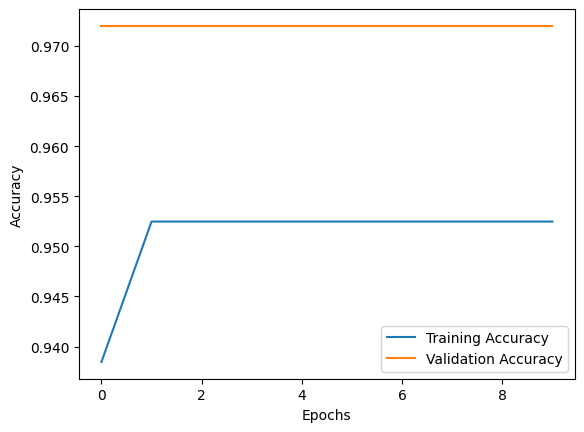

In [48]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

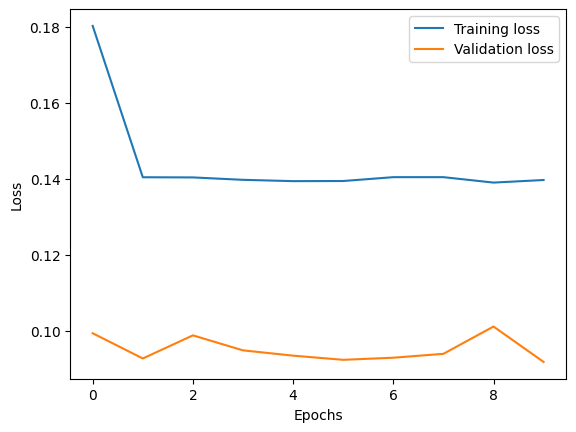

In [49]:
plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [50]:
plt.figure(figsize=(10, 6))
plt.plot(auc_values, label='AUC')
plt.xlabel('Epochs')
plt.ylabel('AUC')
plt.title('AUC vs. Epochs')
plt.legend()
plt.show()

NameError: name 'auc_values' is not defined

<Figure size 1000x600 with 0 Axes>

In [ ]:
import numpy as np
import pandas as pd
from tensorflow.keras.models import load_model

# Load the trained LSTM model
loaded_model = load_model("trained_lstm3_model.h5")

# Predict using the loaded model
predictions = loaded_model.predict(X_test)

# Convert the probabilities to class labels
predicted_classes = np.argmax(predictions, axis=1)


# Create a DataFrame to store the predictions and tweet IDs
output_df = pd.DataFrame({ 'Predicted_Class': predicted_classes})

# Display the DataFrame
print(output_df)


16/16 [==============================] - 5s 33ms/step
     Predicted_Class
0                  0
1                  0
2                  0
3                  0
4                  0
..               ...
495                0
496                0
497                0
498                0
499                0

[500 rows x 1 columns]


METADATA-FEATURES-TWEETS

In [ ]:
df = pd.read_csv("D:\RPP\SOCIAL TWEETS-CODE\social-tweets(10061).csv",low_memory=False)
metadata = df[["num_hashtags", "num_urls", "truncated", "retweet_count", "favorite_count",
                "in_reply_to_status_id", "in_reply_to_user_id", "geo", "place"]]
if "in_reply_to_status_id" in metadata.columns:
    metadata = metadata.drop("in_reply_to_user_id", axis=1)
else:
    metadata = metadata.drop("in_reply_to_status_id", axis=1)
# Save the extracted metadata as a separate CSV file
metadata.to_csv("D:\RPP\SOCIAL TWEETS-CODE\socialmetadatatweet.csv", index=False)

In [ ]:
metadata_df = pd.read_csv("D:\RPP\SOCIAL TWEETS-CODE\socialmetadatatweet.csv",low_memory=False)
metadata_df.columns
metadata_df.dropna()

,num_hashtags,num_urls,truncated,retweet_count,favorite_count,in_reply_to_status_id,geo,place


In [ ]:
metadata_df.dtypes

num_hashtags               int64
num_urls                   int64
truncated                float64
retweet_count              int64
favorite_count             int64
in_reply_to_status_id    float64
geo                      float64
place                    float64
dtype: object

In [ ]:
columns_to_convert = ['num_hashtags', 'num_urls', 'truncated', 'retweet_count', 'favorite_count', 'in_reply_to_status_id', 'geo', 'place']
# Convert specified columns to integer
metadata_df[columns_to_convert] = df[columns_to_convert].replace([np.inf, -np.inf, np.nan], 0)
metadata_df[columns_to_convert] = df[columns_to_convert].astype(int)

# Check the updated data types
print(metadata_df.dtypes)

IntCastingNaNError: Cannot convert non-finite values (NA or inf) to integer

In [ ]:
output_df.columns

Index(['Predicted_Class'], dtype='object')

In [ ]:
from keras.models import Sequential, Model
from keras.layers import Input, Embedding, LSTM, Dense, concatenate
from keras.callbacks import Callback
import pandas as pd
from sklearn.model_selection import train_test_split
df  = pd.concat([output_df, metadata_df], axis=1)
# Create input layers for tweet content and metadata features
input_tweet_content = Input(shape=(max_sequence_length,), name='tweet_content_input')
input_metadata = Input(shape=(metadata_df.shape[1]-1,), name='metadata_input') 
# Embedding layer for tweet content
embedding_dim = 200
embedded_tweet_content = Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_sequence_length)(input_tweet_content)
# LSTM layer for tweet content
lstm_output_tc = LSTM(units=100, return_sequences=False)(embedded_tweet_content)
# Concatenate LSTM output with metadata input
merged_output = concatenate([lstm_output_tc, input_metadata])
# Dense layer for the combined output
output = Dense(units=num_classes, activation='softmax')(merged_output)
# Create the model
model = Model(inputs=[input_tweet_content, input_metadata], outputs=output)
# Compile the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])


In [ ]:
from tensorflow.keras.models import load_model
model.summary()
# Saving the model 
model.save("combined_lstm_output_model.h5")

Model: "model_2"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 tweet_content_input (Input  [(None, 26)]                 0         []                            
 Layer)                                                                                           
                                                                                                  
 embedding_4 (Embedding)     (None, 26, 200)              3068800   ['tweet_content_input[0][0]'] 
                                                                                                  
 lstm_14 (LSTM)              (None, 100)                  120400    ['embedding_4[0][0]']         
                                                                                                  
 metadata_input (InputLayer  [(None, 7)]                  0         []                      

C:\Users\My PC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
